In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

tickers = ["SPY", "TLT", "GLD", "EFA", "VNQ", "ITA", "XLE", "MP", "BTC-USD"]
data = yf.download(tickers, start="2015-01-01", end="2026-09-01")["Close"]

# Align everything to the equity trading calendar (using SPY as reference):
# this drops weekends/holidays for BTC-USD too, keeping all series on the same dates
trading_days = data["SPY"].dropna().index
data = data.reindex(trading_days)

data.isna().sum()  # check remaining NaNs per asset (useful for ITA/MP, which may have shorter history)

[*********************100%***********************]  9 of 9 completed


Ticker
BTC-USD       0
EFA           0
GLD           0
ITA           0
MP         1376
SPY           0
TLT           0
VNQ           0
XLE           0
dtype: int64

In [2]:
# MP Materials only started trading publicly in late 2020 (former SPAC),
# so trim the whole dataset to the period where all assets have data
first_valid = data["MP"].first_valid_index()
data = data.loc[first_valid:]

print(f"Analysis period: {data.index[0].date()} to {data.index[-1].date()}")
data.isna().sum()

Analysis period: 2020-06-22 to 2026-08-31


Ticker
BTC-USD    0
EFA        0
GLD        0
ITA        0
MP         0
SPY        0
TLT        0
VNQ        0
XLE        0
dtype: int64

In [3]:
# Simple (arithmetic) returns — required here, not log returns.
# Portfolio return = weighted sum of simple returns of its components;
# log returns are additive across TIME but not across ASSETS, so they'd
# give a wrong portfolio-level return once we start assigning weights.
returns = data.pct_change().dropna()

returns.describe()

Ticker,BTC-USD,EFA,GLD,ITA,MP,SPY,TLT,VNQ,XLE
count,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000
mean,0.002004,0.000525,0.000649,0.000758,0.002101,0.000690,-0.000267,0.000342,0.001067
std,0.036224,0.010258,0.011482,0.013400,0.045656,0.010551,0.009549,0.011714,0.017741
min,-0.226807,-0.065986,-0.102742,-0.084382,-0.182724,-0.058543,-0.034183,-0.049989,-0.091999
25%,-0.016068,-0.005271,-0.004948,-0.006995,-0.024904,-0.004414,-0.006452,-0.006437,-0.009096
50%,0.000724,0.000741,0.000725,0.001021,-0.000601,0.000900,-0.000226,0.000488,0.001530
75%,0.019066,0.006579,0.006817,0.008231,0.024833,0.006545,0.005643,0.007240,0.010717
max,0.211097,0.077165,0.063587,0.090466,0.506160,0.105019,0.038474,0.073146,0.142759


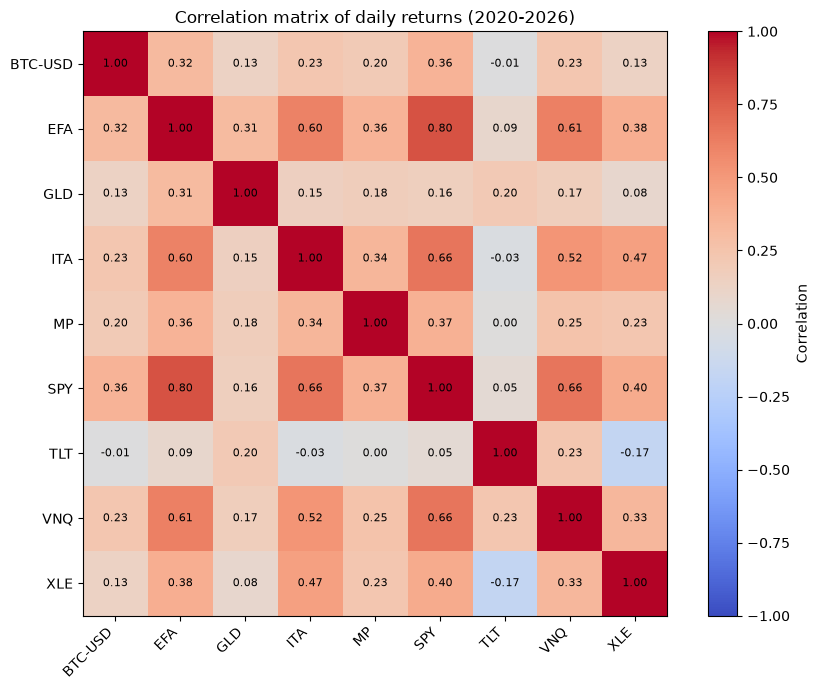

In [4]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
fig.colorbar(im, label="Correlation")

# Print correlation values on top of each cell
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Correlation matrix of daily returns (2020-2026)")
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150)
plt.show()

In [5]:
# Annualize daily stats (252 trading days/year is the market-standard convention)
mean_returns_annual = returns.mean() * 252
cov_matrix_annual = returns.cov() * 252

print("Annualized expected returns:")
print(mean_returns_annual.round(3))

print("\nAnnualized variance (diagonal of covariance matrix):")
print(np.diag(cov_matrix_annual).round(3))
print("(order:", list(cov_matrix_annual.columns), ")")

Annualized expected returns:
Ticker
BTC-USD    0.505
EFA        0.132
GLD        0.164
ITA        0.191
MP         0.529
SPY        0.174
TLT       -0.067
VNQ        0.086
XLE        0.269
dtype: float64

Annualized variance (diagonal of covariance matrix):
[0.331 0.027 0.033 0.045 0.525 0.028 0.023 0.035 0.079]
(order: ['BTC-USD', 'EFA', 'GLD', 'ITA', 'MP', 'SPY', 'TLT', 'VNQ', 'XLE'] )


In [6]:

from scipy.optimize import minimize

def optimize_sharpe(mean_returns, cov_matrix, tickers, fixed_weights=None, risk_free_rate=0.02):
    """
    Finds the max-Sharpe portfolio over `tickers`.
    fixed_weights: optional dict {ticker: weight} to lock specific assets
    (e.g. the satellite bold bet) while the optimizer allocates the rest.
    """
    n = len(tickers)
    mu = mean_returns[tickers].values
    cov = cov_matrix.loc[tickers, tickers].values

    def neg_sharpe(w):
        port_return = np.dot(w, mu)
        port_vol = np.sqrt(w @ cov @ w)
        return -(port_return - risk_free_rate) / port_vol

    bounds = []
    for t in tickers:
        if fixed_weights and t in fixed_weights:
            f = fixed_weights[t]
            bounds.append((f, f))  # locked
        else:
            bounds.append((0, 1))  # no short-selling

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
    init_guess = np.array([1 / n] * n)

    result = minimize(neg_sharpe, init_guess, method="SLSQP",
                       bounds=bounds, constraints=constraints)
    return pd.Series(result.x, index=tickers)

In [7]:
# Portfolio A - baseline diversified, no thesis
tickers_A = ["SPY", "TLT", "GLD", "EFA", "VNQ"]
weights_A = optimize_sharpe(mean_returns_annual, cov_matrix_annual, tickers_A)

# Portfolio B - geopolitical hedge + rare earth bold bet
tickers_B = ["SPY", "TLT", "GLD", "ITA", "XLE", "MP"]
weights_B = optimize_sharpe(mean_returns_annual, cov_matrix_annual, tickers_B,
                             fixed_weights={"MP": 0.07})

# Portfolio C - geopolitical hedge + crypto bold bet (same fixed weight, for a fair comparison)
tickers_C = ["SPY", "TLT", "GLD", "ITA", "XLE", "BTC-USD"]
weights_C = optimize_sharpe(mean_returns_annual, cov_matrix_annual, tickers_C,
                             fixed_weights={"BTC-USD": 0.07})

weights_table = pd.DataFrame({
    "A_baseline": weights_A,
    "B_rare_earth": weights_B,
    "C_crypto": weights_C
}).fillna(0).round(3)

weights_table

,A_baseline,B_rare_earth,C_crypto
BTC-USD,0.000,0.000,0.070
EFA,0.000,0.000,0.000
GLD,0.426,0.381,0.382
ITA,0.000,0.016,0.049
MP,0.000,0.070,0.000
SPY,0.574,0.296,0.271
TLT,0.000,0.000,0.000
VNQ,0.000,0.000,0.000
XLE,0.000,0.237,0.227


In [8]:
def portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate=0.02):
    mu = mean_returns[weights.index].values
    cov = cov_matrix.loc[weights.index, weights.index].values
    port_return = np.dot(weights.values, mu)
    port_vol = np.sqrt(weights.values @ cov @ weights.values)
    sharpe = (port_return - risk_free_rate) / port_vol
    return pd.Series({"Return": port_return, "Volatility": port_vol, "Sharpe": sharpe})

performance_table = pd.DataFrame({
    "A_baseline": portfolio_performance(weights_A, mean_returns_annual, cov_matrix_annual),
    "B_rare_earth": portfolio_performance(weights_B, mean_returns_annual, cov_matrix_annual),
    "C_crypto": portfolio_performance(weights_C, mean_returns_annual, cov_matrix_annual),
}).round(3)

performance_table

,A_baseline,B_rare_earth,C_crypto
Return,0.169,0.218,0.216
Volatility,0.133,0.155,0.146
Sharpe,1.124,1.271,1.343


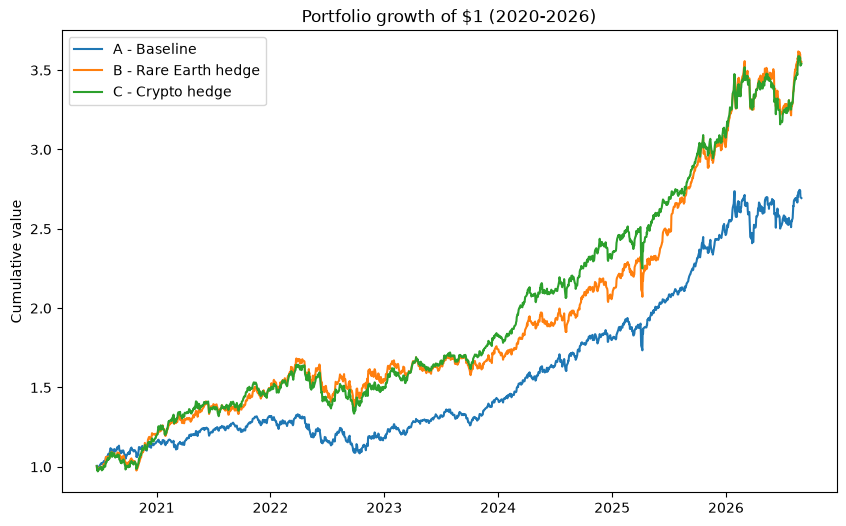

In [9]:
def portfolio_cumulative_returns(weights, returns_df):
    """
    Builds the realized daily return series of a portfolio given fixed weights,
    then compounds it into a cumulative growth curve (starting at 1.0).
    """
    aligned_weights = weights.reindex(returns_df.columns).fillna(0)
    portfolio_daily_returns = returns_df @ aligned_weights
    cumulative = (1 + portfolio_daily_returns).cumprod()
    return portfolio_daily_returns, cumulative

daily_A, cum_A = portfolio_cumulative_returns(weights_A, returns)
daily_B, cum_B = portfolio_cumulative_returns(weights_B, returns)
daily_C, cum_C = portfolio_cumulative_returns(weights_C, returns)

plt.figure(figsize=(10, 6))
plt.plot(cum_A, label="A - Baseline")
plt.plot(cum_B, label="B - Rare Earth hedge")
plt.plot(cum_C, label="C - Crypto hedge")
plt.title("Portfolio growth of $1 (2020-2026)")
plt.ylabel("Cumulative value")
plt.legend()
plt.savefig("cumulative_returns.png", dpi=150)
plt.show()

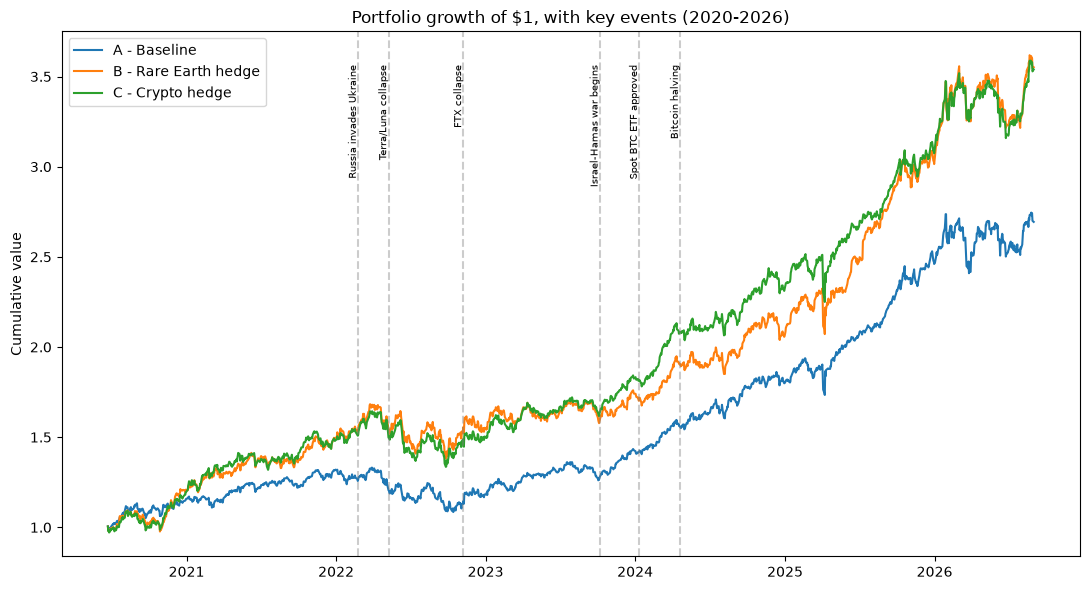

In [10]:
import matplotlib.dates as mdates

# Key event dates for annotation (verify exact dates before finalizing README)
events = {
    "2022-02-24": "Russia invades Ukraine",
    "2022-05-09": "Terra/Luna collapse",
    "2022-11-08": "FTX collapse",
    "2023-10-07": "Israel-Hamas war begins",
    "2024-01-11": "Spot BTC ETF approved",
    "2024-04-20": "Bitcoin halving",
}

plt.figure(figsize=(11, 6))
plt.plot(cum_A, label="A - Baseline", color="tab:blue")
plt.plot(cum_B, label="B - Rare Earth hedge", color="tab:orange")
plt.plot(cum_C, label="C - Crypto hedge", color="tab:green")

for date_str, label in events.items():
    date = pd.to_datetime(date_str)
    if date in cum_A.index or (cum_A.index[0] <= date <= cum_A.index[-1]):
        plt.axvline(date, color="gray", linestyle="--", alpha=0.4)
        plt.text(date, plt.ylim()[1]*0.95, label, rotation=90,
                  fontsize=7, ha="right", va="top")

plt.title("Portfolio growth of $1, with key events (2020-2026)")
plt.ylabel("Cumulative value")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig("cumulative_returns_annotated.png", dpi=150)
plt.show()


In [11]:
def window_return(cum_series, start, end):
    """Return of the portfolio between two dates (using cumulative growth series)."""
    start, end = pd.to_datetime(start), pd.to_datetime(end)
    window = cum_series.loc[start:end]
    return (window.iloc[-1] / window.iloc[0]) - 1

def max_drawdown(cum_series, start=None, end=None):
    """Max peak-to-trough decline within a given window (or the whole series)."""
    series = cum_series if start is None else cum_series.loc[start:end]
    running_max = series.cummax()
    drawdown = series / running_max - 1
    return drawdown.min()

# Geopolitical events -> thesis expects B (rare earth) to hold up better
geo_windows = {
    "Ukraine invasion (Feb-Mar 2022)": ("2022-02-24", "2022-03-24"),
    "Israel-Hamas war (Oct-Nov 2023)": ("2023-10-07", "2023-11-07"),
}

# Crypto-idiosyncratic events -> thesis expects C (crypto) to suffer, unrelated to geopolitics
crypto_windows = {
    "Terra/Luna collapse (May-Jun 2022)": ("2022-05-07", "2022-06-07"),
    "FTX collapse (Nov-Dec 2022)": ("2022-11-06", "2022-12-06"),
}

all_windows = {**geo_windows, **crypto_windows}

results = []
for name, (start, end) in all_windows.items():
    results.append({
        "Event": name,
        "A_baseline": window_return(cum_A, start, end),
        "B_rare_earth": window_return(cum_B, start, end),
        "C_crypto": window_return(cum_C, start, end),
    })

event_table = pd.DataFrame(results).set_index("Event").round(3)
event_table


,A_baseline,B_rare_earth,C_crypto
Event,,,
Ukraine invasion (Feb-Mar 2022),0.048,0.090,0.080
Israel-Hamas war (Oct-Nov 2023),0.031,0.011,0.033
Terra/Luna collapse (May-Jun 2022),0.026,0.070,0.065
FTX collapse (Nov-Dec 2022),0.046,0.012,0.002


In [12]:
drawdown_results = []
for name, (start, end) in all_windows.items():
    drawdown_results.append({
        "Event": name,
        "A_baseline": max_drawdown(cum_A, start, end),
        "B_rare_earth": max_drawdown(cum_B, start, end),
        "C_crypto": max_drawdown(cum_C, start, end),
    })

drawdown_table = pd.DataFrame(drawdown_results).set_index("Event").round(3)
drawdown_table


,A_baseline,B_rare_earth,C_crypto
Event,,,
Ukraine invasion (Feb-Mar 2022),-0.023,-0.039,-0.033
Israel-Hamas war (Oct-Nov 2023),-0.018,-0.029,-0.010
Terra/Luna collapse (May-Jun 2022),-0.023,-0.021,-0.022
FTX collapse (Nov-Dec 2022),-0.027,-0.037,-0.030


In [13]:
def risk_contribution(weights, cov_matrix):
    """
    Splits total portfolio volatility into each asset's contribution.
    The contributions sum exactly to the portfolio's total volatility,
    so this shows *where* the risk actually comes from - not just how
    much weight each asset has.
    """
    w = weights.values
    cov = cov_matrix.loc[weights.index, weights.index].values
    port_vol = np.sqrt(w @ cov @ w)
    marginal_contrib = (cov @ w) / port_vol
    component_contrib = w * marginal_contrib
    pct_contrib = component_contrib / port_vol * 100

    return pd.DataFrame({
        "Weight_%": w * 100,
        "Risk_contribution_%": pct_contrib
    }, index=weights.index).round(1)

risk_contribution(weights_B, cov_matrix_annual)


,Weight_%,Risk_contribution_%
SPY,29.6,22.3
TLT,0.0,0.0
GLD,38.1,26.6
ITA,1.6,1.4
XLE,23.7,29.1
MP,7.0,20.6


In [14]:
def full_period_stats(cum_series, daily_returns, risk_free_rate=0.02):
    total_return = cum_series.iloc[-1] - 1
    n_years = (cum_series.index[-1] - cum_series.index[0]).days / 365.25
    cagr = cum_series.iloc[-1] ** (1 / n_years) - 1
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = (cagr - risk_free_rate) / ann_vol
    return pd.Series({
        "Total return": total_return,
        "CAGR": cagr,
        "Annualized volatility": ann_vol,
        "Realized Sharpe": sharpe,
        "Max drawdown (full period)": max_drawdown(cum_series),
    })

summary_table = pd.DataFrame({
    "A_baseline": full_period_stats(cum_A, daily_A),
    "B_rare_earth": full_period_stats(cum_B, daily_B),
    "C_crypto": full_period_stats(cum_C, daily_C),
}).round(3)

summary_table


,A_baseline,B_rare_earth,C_crypto
Total return,1.694,2.552,2.539
CAGR,0.174,0.227,0.227
Annualized volatility,0.133,0.155,0.146
Realized Sharpe,1.156,1.334,1.420
Max drawdown (full period),-0.185,-0.180,-0.188


In [15]:
def drawdown_series(cum_series):
    running_max = cum_series.cummax()
    return cum_series / running_max - 1

for name, cum in [("A_baseline", cum_A), ("B_rare_earth", cum_B), ("C_crypto", cum_C)]:
    dd = drawdown_series(cum)
    worst_date = dd.idxmin()
    print(f"{name}: worst drawdown {dd.min():.3f} on {worst_date.date()}")


A_baseline: worst drawdown -0.185 on 2022-10-14
B_rare_earth: worst drawdown -0.180 on 2022-09-26
C_crypto: worst drawdown -0.188 on 2022-09-26


In [16]:
def var_cvar(daily_returns, confidence=0.95):
    """
    Historical VaR/CVaR: no distributional assumption (unlike parametric VaR),
    just the empirical worst-tail outcomes actually observed.
    """
    var = -np.percentile(daily_returns, (1 - confidence) * 100)
    cvar = -daily_returns[daily_returns <= -var].mean()
    return pd.Series({"VaR_95": var, "CVaR_95": cvar})

risk_table = pd.DataFrame({
    "A_baseline": var_cvar(daily_A),
    "B_rare_earth": var_cvar(daily_B),
    "C_crypto": var_cvar(daily_C),
}).round(4)

risk_table


,A_baseline,B_rare_earth,C_crypto
VaR_95,0.0131,0.0151,0.0145
CVaR_95,0.0194,0.0218,0.0214


In [17]:
# Split: optimize weights on 2020-2023 only, then apply them untouched to 2024-2026.
# This removes the look-ahead bias of optimizing and evaluating on the same data.
split_date = "2024-01-01"

returns_train = returns.loc[:split_date]
returns_test = returns.loc[split_date:]

mean_train = returns_train.mean() * 252
cov_train = returns_train.cov() * 252

# Re-optimize using ONLY training data
weights_A_oos = optimize_sharpe(mean_train, cov_train, tickers_A)
weights_B_oos = optimize_sharpe(mean_train, cov_train, tickers_B, fixed_weights={"MP": 0.07})
weights_C_oos = optimize_sharpe(mean_train, cov_train, tickers_C, fixed_weights={"BTC-USD": 0.07})

# Apply those frozen weights to the unseen test period
daily_A_oos, cum_A_oos = portfolio_cumulative_returns(weights_A_oos, returns_test)
daily_B_oos, cum_B_oos = portfolio_cumulative_returns(weights_B_oos, returns_test)
daily_C_oos, cum_C_oos = portfolio_cumulative_returns(weights_C_oos, returns_test)

oos_table = pd.DataFrame({
    "A_baseline": full_period_stats(cum_A_oos, daily_A_oos),
    "B_rare_earth": full_period_stats(cum_B_oos, daily_B_oos),
    "C_crypto": full_period_stats(cum_C_oos, daily_C_oos),
}).round(3)

print("OUT-OF-SAMPLE (2024-2026), weights fixed using 2020-2023 data only:")
oos_table

OUT-OF-SAMPLE (2024-2026), weights fixed using 2020-2023 data only:


,A_baseline,B_rare_earth,C_crypto
Total return,0.743,0.866,0.826
CAGR,0.232,0.264,0.254
Annualized volatility,0.143,0.159,0.140
Realized Sharpe,1.483,1.532,1.665
Max drawdown (full period),-0.160,-0.155,-0.147


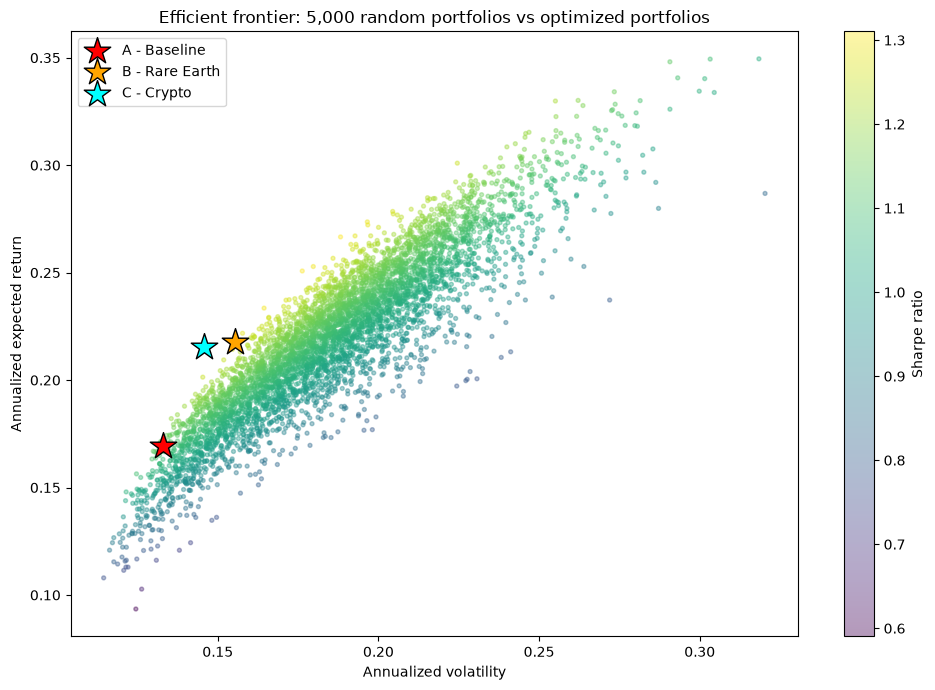

In [18]:
# Monte Carlo: simulate random portfolios to visualize the feasible risk-return space,
# then overlay our three actual portfolios to see where they sit.
np.random.seed(42)
n_portfolios = 5000
universe = ["SPY", "TLT", "GLD", "EFA", "VNQ", "ITA", "XLE", "MP", "BTC-USD"]

mu_universe = mean_returns_annual[universe].values
cov_universe = cov_matrix_annual.loc[universe, universe].values

sim_returns, sim_vols = [], []
for _ in range(n_portfolios):
    w = np.random.random(len(universe))
    w /= w.sum()
    sim_returns.append(w @ mu_universe)
    sim_vols.append(np.sqrt(w @ cov_universe @ w))

sim_returns, sim_vols = np.array(sim_returns), np.array(sim_vols)
sim_sharpe = (sim_returns - 0.02) / sim_vols

plt.figure(figsize=(10, 7))
plt.scatter(sim_vols, sim_returns, c=sim_sharpe, cmap="viridis", s=8, alpha=0.4)
plt.colorbar(label="Sharpe ratio")

# Overlay the three portfolios
for label, weights, color in [("A - Baseline", weights_A, "red"),
                               ("B - Rare Earth", weights_B, "orange"),
                               ("C - Crypto", weights_C, "cyan")]:
    perf = portfolio_performance(weights, mean_returns_annual, cov_matrix_annual)
    plt.scatter(perf["Volatility"], perf["Return"], marker="*", s=400,
                color=color, edgecolors="black", linewidths=1, label=label, zorder=5)

plt.xlabel("Annualized volatility")
plt.ylabel("Annualized expected return")
plt.title("Efficient frontier: 5,000 random portfolios vs optimized portfolios")
plt.legend()
plt.tight_layout()
plt.savefig("efficient_frontier.png", dpi=150)
plt.show()

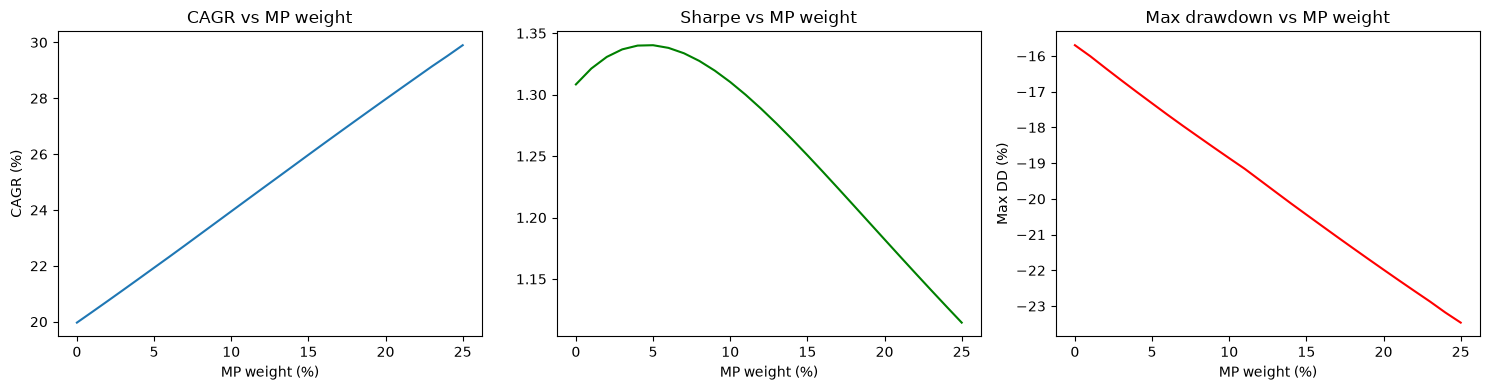

Sharpe-maximizing MP weight: 5% (Sharpe 1.340)


In [19]:
# How does portfolio performance change as the bold bet weight varies from 0% to 25%?
weight_grid = np.arange(0, 0.26, 0.01)
sensitivity_results = []

for w_bold in weight_grid:
    if w_bold == 0:
        w_B = optimize_sharpe(mean_returns_annual, cov_matrix_annual,
                               ["SPY", "TLT", "GLD", "ITA", "XLE"])
    else:
        w_B = optimize_sharpe(mean_returns_annual, cov_matrix_annual, tickers_B,
                               fixed_weights={"MP": w_bold})

    daily_tmp, cum_tmp = portfolio_cumulative_returns(w_B, returns)
    stats = full_period_stats(cum_tmp, daily_tmp)
    sensitivity_results.append({
        "MP_weight": w_bold,
        "CAGR": stats["CAGR"],
        "Sharpe": stats["Realized Sharpe"],
        "MaxDrawdown": stats["Max drawdown (full period)"],
    })

sensitivity_df = pd.DataFrame(sensitivity_results)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(sensitivity_df["MP_weight"] * 100, sensitivity_df["CAGR"] * 100)
axes[0].set_title("CAGR vs MP weight"); axes[0].set_xlabel("MP weight (%)"); axes[0].set_ylabel("CAGR (%)")

axes[1].plot(sensitivity_df["MP_weight"] * 100, sensitivity_df["Sharpe"], color="green")
axes[1].set_title("Sharpe vs MP weight"); axes[1].set_xlabel("MP weight (%)")

axes[2].plot(sensitivity_df["MP_weight"] * 100, sensitivity_df["MaxDrawdown"] * 100, color="red")
axes[2].set_title("Max drawdown vs MP weight"); axes[2].set_xlabel("MP weight (%)"); axes[2].set_ylabel("Max DD (%)")

plt.tight_layout()
plt.savefig("bold_bet_sensitivity.png", dpi=150)
plt.show()

# Find the weight that maximizes Sharpe
best = sensitivity_df.loc[sensitivity_df["Sharpe"].idxmax()]
print(f"Sharpe-maximizing MP weight: {best['MP_weight']:.0%} (Sharpe {best['Sharpe']:.3f})")

In [20]:
from src.factors import get_fama_french_factors

ff_factors = get_fama_french_factors(start="2020-01-01")
ff_factors.head()

,Mkt-RF,SMB,HML,RF
Date,,,,
2020-01-02,0.0086,-0.0088,-0.0034,0.0001
2020-01-03,-0.0067,0.0038,0.0001,0.0001
2020-01-06,0.0036,-0.0007,-0.0055,0.0001
2020-01-07,-0.0019,-0.0001,-0.0026,0.0001
2020-01-08,0.0047,-0.0007,-0.0064,0.0001


In [21]:
def get_fama_french_factors(start=None, end=None):
    """
    Download the Fama-French 3-factor (daily) dataset from
    Kenneth French's Data Library.

    Returns a DataFrame with columns Mkt-RF, SMB, HML, RF,
    converted to decimal format (raw data comes in percent).
    """
    raw = web.DataReader(
        "F-F_Research_Data_Factors_daily", "famafrench", start=start, end=end
    )
    factors = raw[0] / 100
    return factors


def align_returns_with_factors(portfolio_returns, factors):
    """
    Align a portfolio's daily returns with the Fama-French factors
    on matching dates, and compute the excess return (return - RF).
    """
    combined = factors.join(portfolio_returns.rename("portfolio"), how="inner")
    combined["portfolio_excess"] = combined["portfolio"] - combined["RF"]
    return combined

In [22]:
type(ff_factors.index)

pandas.PeriodIndex

In [23]:
if isinstance(ff_factors.index, pd.PeriodIndex):
    ff_factors.index = ff_factors.index.to_timestamp()

In [24]:
from src.factors import align_returns_with_factors

reg_data_A = align_returns_with_factors(daily_A, ff_factors)
reg_data_A.head()

,Mkt-RF,SMB,HML,RF,portfolio,portfolio_excess
Date,,,,,,
2020-06-23,0.0041,0.0017,-0.0060,0.0,0.006229,0.006229
2020-06-24,-0.0262,-0.0045,-0.0136,0.0,-0.016128,-0.016128
2020-06-25,0.0113,0.0025,0.0050,0.0,0.005898,0.005898
2020-06-26,-0.0243,0.0012,-0.0139,0.0,-0.011735,-0.011735
2020-06-29,0.0150,0.0125,0.0186,0.0,0.008668,0.008668


In [25]:
portfolios_daily = {"A": daily_A, "B": daily_B, "C": daily_C}

reg_data = {
    name: align_returns_with_factors(returns, ff_factors)
    for name, returns in portfolios_daily.items()
}

reg_data["B"].head()

,Mkt-RF,SMB,HML,RF,portfolio,portfolio_excess
Date,,,,,,
2020-06-23,0.0041,0.0017,-0.0060,0.0,0.004026,0.004026
2020-06-24,-0.0262,-0.0045,-0.0136,0.0,-0.023637,-0.023637
2020-06-25,0.0113,0.0025,0.0050,0.0,0.008386,0.008386
2020-06-26,-0.0243,0.0012,-0.0139,0.0,-0.013551,-0.013551
2020-06-29,0.0150,0.0125,0.0186,0.0,0.008866,0.008866


In [26]:
import statsmodels
print(statsmodels.__version__)

0.15.0


In [27]:
import src.factors
print(src.factors.__file__)
print(dir(src.factors))

/Users/maddalena/Documents/portfolio-optimizer/src/factors.py
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'align_returns_with_factors', 'get_fama_french_factors', 'run_factor_regression', 'sm', 'web']


In [28]:
from src.factors import run_factor_regression

model_A = run_factor_regression(reg_data["A"])
print(model_A.summary())

                            OLS Regression Results                            
Dep. Variable:       portfolio_excess   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.669
Method:                 Least Squares   F-statistic:                     1035.
Date:                Tue, 15 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:34:41   Log-Likelihood:                 6011.3
No. Observations:                1534   AIC:                        -1.201e+04
Df Residuals:                    1530   BIC:                        -1.199e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      1.391      0.1

In [29]:
model_B = run_factor_regression(reg_data["B"])
print(model_B.summary())

model_C = run_factor_regression(reg_data["C"])
print(model_C.summary())

                            OLS Regression Results                            
Dep. Variable:       portfolio_excess   R-squared:                       0.566
Model:                            OLS   Adj. R-squared:                  0.565
Method:                 Least Squares   F-statistic:                     665.2
Date:                Tue, 15 Sep 2026   Prob (F-statistic):          1.07e-276
Time:                        12:34:42   Log-Likelihood:                 5558.7
No. Observations:                1534   AIC:                        -1.111e+04
Df Residuals:                    1530   BIC:                        -1.109e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      1.514      0.1

In [30]:
model_B = run_factor_regression(reg_data["B"])
print(model_B.summary())

model_C = run_factor_regression(reg_data["C"])
print(model_C.summary())

                            OLS Regression Results                            
Dep. Variable:       portfolio_excess   R-squared:                       0.566
Model:                            OLS   Adj. R-squared:                  0.565
Method:                 Least Squares   F-statistic:                     665.2
Date:                Tue, 15 Sep 2026   Prob (F-statistic):          1.07e-276
Time:                        12:34:42   Log-Likelihood:                 5558.7
No. Observations:                1534   AIC:                        -1.111e+04
Df Residuals:                    1530   BIC:                        -1.109e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      1.514      0.1

In [31]:
model_A_robust = run_factor_regression(reg_data["A"], robust=True)
print(model_A_robust.summary())

                            OLS Regression Results                            
Dep. Variable:       portfolio_excess   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.669
Method:                 Least Squares   F-statistic:                     479.6
Date:                Tue, 15 Sep 2026   Prob (F-statistic):          1.31e-219
Time:                        12:34:42   Log-Likelihood:                 6011.3
No. Observations:                1534   AIC:                        -1.201e+04
Df Residuals:                    1530   BIC:                        -1.199e+04
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      1.435      0.1

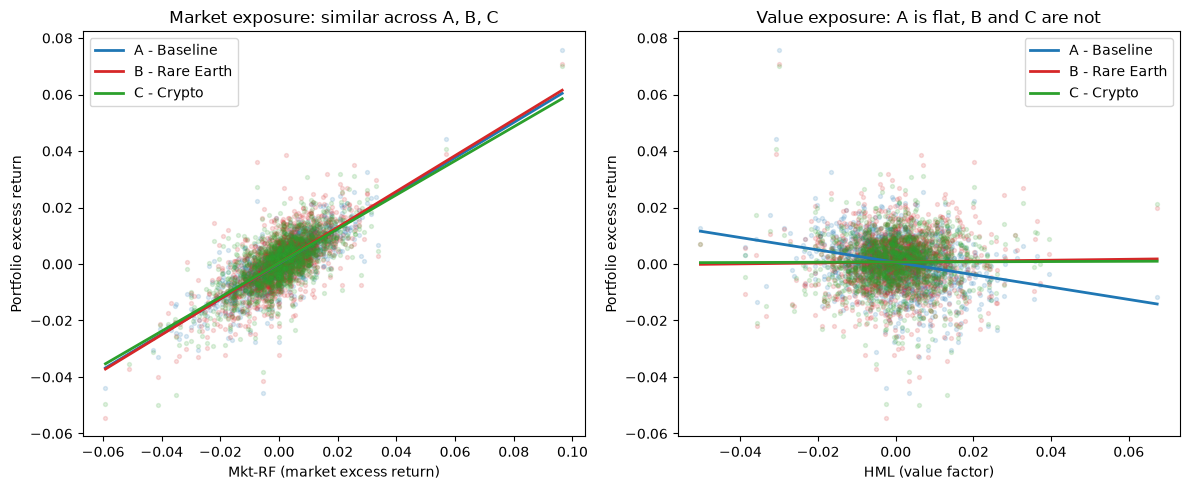

In [35]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {"A": "#1f77b4", "B": "#d62728", "C": "#2ca02c"}
labels = {"A": "A - Baseline", "B": "B - Rare Earth", "C": "C - Crypto"}

# Left: excess return vs market factor
for name in ["A", "B", "C"]:
    data = reg_data[name]
    x, y = data["Mkt-RF"], data["portfolio_excess"]
    axes[0].scatter(x, y, s=8, alpha=0.15, color=colors[name])
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    axes[0].plot(x_line, slope * x_line + intercept, color=colors[name], linewidth=2, label=labels[name])
axes[0].set_xlabel("Mkt-RF (market excess return)")
axes[0].set_ylabel("Portfolio excess return")
axes[0].set_title("Market exposure: similar across A, B, C")
axes[0].legend()

# Right: excess return vs value factor
for name in ["A", "B", "C"]:
    data = reg_data[name]
    x, y = data["HML"], data["portfolio_excess"]
    axes[1].scatter(x, y, s=8, alpha=0.15, color=colors[name])
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    axes[1].plot(x_line, slope * x_line + intercept, color=colors[name], linewidth=2, label=labels[name])
axes[1].set_xlabel("HML (value factor)")
axes[1].set_ylabel("Portfolio excess return")
axes[1].set_title("Value exposure: A is flat, B and C are not")
axes[1].legend()

plt.tight_layout()
plt.savefig("factor_exposure.png", dpi=150)
plt.show()

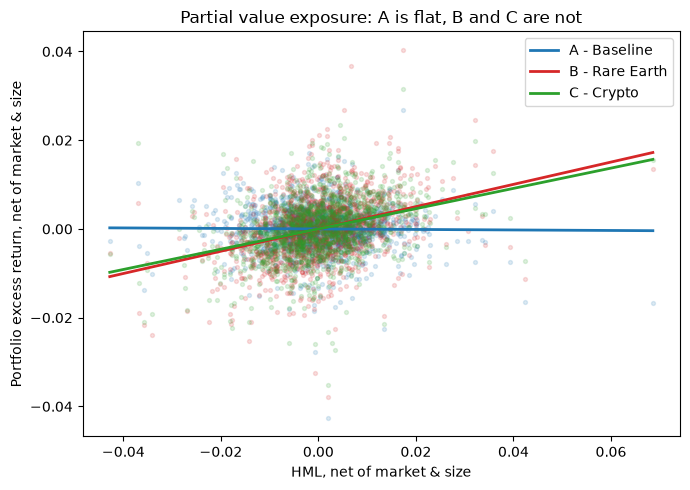

In [33]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 5))
colors = {"A": "#1f77b4", "B": "#d62728", "C": "#2ca02c"}
labels = {"A": "A - Baseline", "B": "B - Rare Earth", "C": "C - Crypto"}

for name in ["A", "B", "C"]:
    data = reg_data[name]
    controls = sm.add_constant(data[["Mkt-RF", "SMB"]])

    # Strip out everything explained by market and size from both variables
    y_resid = sm.OLS(data["portfolio_excess"], controls).fit().resid
    x_resid = sm.OLS(data["HML"], controls).fit().resid

    ax.scatter(x_resid, y_resid, s=8, alpha=0.15, color=colors[name])
    slope, intercept = np.polyfit(x_resid, y_resid, 1)
    x_line = np.linspace(x_resid.min(), x_resid.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color=colors[name], linewidth=2, label=labels[name])

ax.set_xlabel("HML, net of market & size")
ax.set_ylabel("Portfolio excess return, net of market & size")
ax.set_title("Partial value exposure: A is flat, B and C are not")
ax.legend()
plt.tight_layout()
plt.savefig("factor_exposure_hml_partial.png", dpi=150)
plt.show()